# Read in the split data and load the YAML metadata

In [1]:
# Import the required modules

import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import numpy as np
import scipy as sp
import yaml
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import (
    HalvingGridSearchCV,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
    KFold,
)
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
from sklearn.base import clone

from sklearn.metrics import silhouette_score, davies_bouldin_score


In [2]:
# Import the split data
X_train_path = 'bin/X_train.csv'
y_train_path = 'bin/y_train.csv'
X_test_path = 'bin/X_test.csv'
y_test_path = 'bin/y_test.csv'

X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path)
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path)


USE_SUBSET  = True          # flip to False for full data
SUBSET_FRAC = 0.1
SEED        = 42

if USE_SUBSET:
    idx_train = X_train.sample(frac=SUBSET_FRAC, random_state=SEED).index
    X_train   = X_train.loc[idx_train].reset_index(drop=True)
    y_train   = y_train.loc[idx_train].reset_index(drop=True)

    idx_test  = X_test.sample(frac=SUBSET_FRAC, random_state=SEED).index
    X_test    = X_test.loc[idx_test].reset_index(drop=True)
    y_test    = y_test.loc[idx_test].reset_index(drop=True)

    print(f"Using {SUBSET_FRAC:.0%} subset: "
          f"{X_train.shape[0]} train rows, {X_test.shape[0]} test rows")




# flatten target 
target_variable = 'Beta_winsorized'
y_train = y_train[target_variable].values.ravel()
y_test  = y_test[target_variable].values.ravel()

# print the shape of the data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# print the first 5 rows of the data
print(X_train[:5])
print(y_train[:5])
print(X_test[:5])
print(y_test[:5])
	


Using 10% subset: 4043 train rows, 1011 test rows
(4043, 879)
(4043,)
(1011, 879)
(1011,)
    x74r   term    ltv   cltv    dti    pti  age_o1  age_o2  age_o3  \
0  1.081 -0.499 -1.335 -1.347 -0.150  0.277   0.000   0.000   0.000   
1  0.513 -3.223  0.017  0.004  1.046 -0.105   0.000   0.000   0.000   
2  0.513 -1.710 -0.183 -0.196 -1.346 -0.392   0.000   0.000   0.000   
3 -1.260  0.560  1.069  1.055  1.046  1.519   0.000   0.000   0.000   
4 -0.196  0.560  1.119  1.105  1.524  2.284   0.000   0.000   0.000   

   score_orig_r  ...  close_month_5  close_month_6  close_month_7  \
0        -0.240  ...           True          False          False   
1        -0.944  ...          False          False          False   
2         0.816  ...          False          False          False   
3        -1.584  ...          False          False          False   
4        -1.952  ...          False          False          False   

   close_month_8  close_month_9  close_month_10  close_month_11  \
0

In [3]:
# ---- metadata needed for feature-name lookups ----
import yaml

# variable labels (short human-readable descriptions)
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)

# SAS format for each original variable (tells you if cat / numeric)
with open('variable_formats.yaml') as f:
    variable_formats_dict = yaml.safe_load(f)

# mapping from format-name → {category-code: category-text}
with open('categorical_variables_categories.yaml') as f:
    categorical_variables_categories_dict = yaml.safe_load(f)

# list of all one-hot (dummy) columns produced during cleaning
with open('cleaned_variables.yaml') as f:
    cleaned_vars = yaml.safe_load(f)
new_categorical_variables = set(cleaned_vars['categorical_variables'])

In [4]:
# Set the target variable
target_variable = 'Beta_winsorized'

# print the value of the target variable from the training data to validate it loaded correctly
print(pd.Series(y_train, name=target_variable).head())

0   2.797
1   0.934
2   0.946
3   1.322
4   0.763
Name: Beta_winsorized, dtype: float64


# Supervised Learning Models: k-NN LASSO, Gradient Boosting,

### Helper Function

In [5]:
def tune_and_evaluate(
        model_cls, param_grid,
        X_train, y_train, X_test, y_test,
        metric='neg_root_mean_squared_error',
        cv_splits=5, random_state=42,
        label='', search_strategy='grid', n_iter=10, factor=3):

    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # ---- pipeline wrapper only for k-NN ---------------------------
    if issubclass(model_cls, KNeighborsRegressor):
        base = Pipeline([('scale', StandardScaler()),
                         ('knn',   model_cls())])
        param_grid = {('knn__' + k if not k.startswith('knn__') else k): v
                      for k, v in param_grid.items()}
    else:
        base_kwargs = {}
        if 'random_state' in model_cls().get_params():
            base_kwargs['random_state'] = random_state
        base = model_cls(**base_kwargs)

    strategy = {
        'grid':    (GridSearchCV,         {'param_grid': param_grid}),
        'random':  (RandomizedSearchCV,   {'param_distributions': param_grid,
                                           'n_iter': n_iter,
                                           'random_state': random_state}),
        'halving': (HalvingGridSearchCV,  {'param_grid': param_grid,
                                           'factor': factor,
                                           'random_state': random_state})
    }[search_strategy]

    search = strategy[0](estimator=base, scoring=metric, cv=cv,
                         n_jobs=-1, verbose=1, **strategy[1]).fit(X_train, y_train)

    best = search.best_estimator_
    y_pred = best.predict(X_test)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    return best, {'model': f'{label or model_cls.__name__} '
                           f'(tuned – {search_strategy.capitalize()})',
                  'MAE': mae, 'RMSE': rmse,
                  'best_params': search.best_params_,
                  'cv_best_score': search.best_score_}


### Hyper-parameter grids

In [6]:
gb_grid  = {'learning_rate': [.02, .03, .04],
            'max_depth':     [10, 15, 20],
            'max_iter':      [400, 800],
            'l2_regularization': [0, .0005, .001],
            'min_samples_leaf': [10, 20],
            'max_leaf_nodes':   [31, 63]}

lasso_grid = {'alpha': np.logspace(-4, -1, 7), 'max_iter': [5000]}

knn_grid   = {'n_neighbors': [3,5,7,11,15],
              'weights':     ['uniform', 'distance'],
              'p':           [1,2]}            # 1 = Manhattan, 2 = Euclidean


### Train and tune the models

In [7]:
results, best_models = [], {}
for lab, cls, grid in [
        ('GB',    HistGradientBoostingRegressor, gb_grid),
        ('Lasso', Lasso,                         lasso_grid),
        ('k-NN',  KNeighborsRegressor,           knn_grid)]:

    best, res = tune_and_evaluate(cls, grid,
                                  X_train, y_train,
                                  X_test,  y_test,
                                  label=lab,
                                  search_strategy='halving' if lab=='GB' else 'grid')
    best_models[lab], results = best, results + [res]
    print(res)

results_df = (pd.DataFrame(results)
              .set_index('model')
              .sort_values('RMSE'))
display(results_df.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}'}))


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 49
max_resources_: 4043
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 216
n_resources: 49
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 1
n_candidates: 72
n_resources: 147
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 2
n_candidates: 24
n_resources: 441
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 3
n_candidates: 8
n_resources: 1323
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 4
n_candidates: 3
n_resources: 3969
Fitting 5 folds for each of 3 candidates, totalling 15 fits
{'model': 'GB (tuned – Halving)', 'MAE': 0.42344523634721004, 'RMSE': np.float64(0.6112028698834876), 'best_params': {'l2_regularization': 0.0005, 'learning_rate': 0.03, 'max_depth': 20, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}, 'cv_best_score': np.float64(-0.6218518639314231)}
Fitting 5 folds for each of 7 candidates, totalling 35 fits
{'model': 'Lasso (tuned – Grid)', 'MAE': 0.4465210655669043, 'RMSE': np.float64(0.6351860869422706), 'best_params': {'alpha': np.float64(0.0031622776601683794), 'max_iter': 5000}, 'cv_best_score': np.float64(-0.6314707470906713)}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model': 'k-NN (tuned – Grid)', 'MAE': 0.45805774407507627, 'RMSE': np.float64(0.6520229734485364), 'best_params': {'knn

,MAE,RMSE,best_params,cv_best_score
model,,,,
GB (tuned – Halving),0.4234,0.6112,"{'l2_regularization': 0.0005, 'learning_rate': 0.03, 'max_depth': 20, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}",-0.621852
Lasso (tuned – Grid),0.4465,0.6352,"{'alpha': np.float64(0.0031622776601683794), 'max_iter': 5000}",-0.631471
k-NN (tuned – Grid),0.4581,0.6520,"{'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}",-0.657697


In [8]:
#  Gradient Boosting Regression (Cross-Validation)                0.3970                    0.584  {'learning_rate': 0.025, 'max_depth': 10, 'max... 

### Feature-importance & Ablation

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/fy/v4z9p5hj31n955998nz_syv80000gn/T/ipykernel_29269/1607320750.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resu

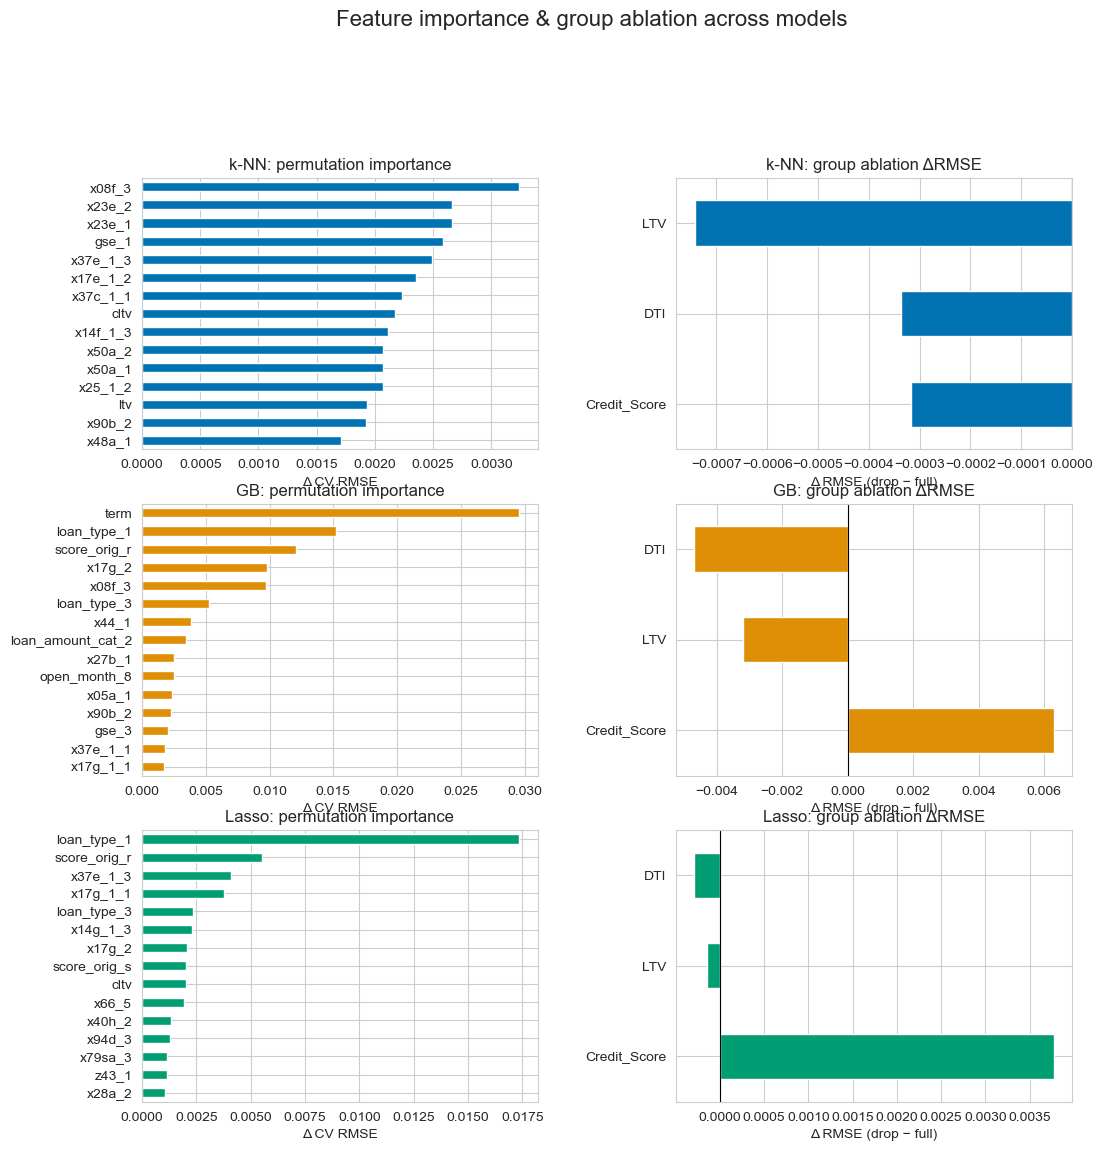

In [9]:
models = {
    'k-NN' : best_models['k-NN'],
    'GB'   : best_models['GB'],
    'Lasso': best_models['Lasso']
}


perm_imps = {}
for name, mdl in models.items():
    fitted = clone(mdl).fit(X_train, y_train)
    perm = permutation_importance(fitted, X_test, y_test,
                                  n_repeats=10, random_state=42,
                                  scoring='neg_root_mean_squared_error',
                                  n_jobs=-1)
    s = pd.Series(perm.importances_mean, index=X_train.columns)
    perm_imps[name] = s.sort_values(ascending=False).head(15)


# Needs further analysis
groups = {
    'Credit_Score': ['score_orig_r', 'score_orig_s'],
    'LTV':          ['ltv', 'cltv'],
    'DTI':          ['dti', 'pti']
}

def rmse_cv(mdl, X, y):
    sc = cross_val_score(clone(mdl), X, y,
                         scoring='neg_root_mean_squared_error',
                         cv=KFold(5, shuffle=True, random_state=42),
                         n_jobs=-1)
    return -sc.mean()

ablations = {}
for name, mdl in models.items():
    base = rmse_cv(mdl, X_train, y_train)
    abl  = {g: rmse_cv(mdl, X_train.drop(columns=cols), y_train) - base
            for g, cols in groups.items()}
    ablations[name] = pd.Series(abl).sort_values()


sns.set_style("whitegrid")
fig, axes = plt.subplots(len(models), 2, figsize=(12, 4*len(models)),
                         gridspec_kw={'wspace':0.35})

palette = sns.color_palette("colorblind", len(models))

for i, (name, imp) in enumerate(perm_imps.items()):
    # (left) permutation importance
    imp[::-1].plot.barh(ax=axes[i,0], color=palette[i])
    axes[i,0].set_title(f'{name}: permutation importance')
    axes[i,0].set_xlabel('Δ CV RMSE')

    # (right) ablation
    ablations[name][::-1].plot.barh(ax=axes[i,1], color=palette[i])
    axes[i,1].set_title(f'{name}: group ablation ΔRMSE')
    axes[i,1].set_xlabel('Δ RMSE (drop − full)')
    axes[i,1].axvline(0, color='k', lw=0.8)

fig.suptitle('Feature importance & group ablation across models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Sensitivity Curves

In [10]:
sns.set_style("whitegrid")

# k-NN (n_neighbors 1–19, odd)
k_vals, knn_rmse, knn_std = [], [], []
for k in range(1, 21, 2):
    mdl = Pipeline([('scale', StandardScaler()),
                    ('knn',  KNeighborsRegressor(n_neighbors=k))])
    sc = cross_val_score(mdl, X_train, y_train,
                         scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    k_vals.append(k); knn_rmse.append(-sc.mean()); knn_std.append(sc.std())
best_k = k_vals[int(np.argmin(knn_rmse))]

# Gradient Boosting (learning_rate 10⁻³ … 1)
rates = np.logspace(-3, 0, 7)
gb_rmse, gb_std = [], []
for lr in rates:
    mdl = HistGradientBoostingRegressor(learning_rate=lr, max_iter=400, random_state=42)
    sc  = cross_val_score(mdl, X_train, y_train,
                          scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    gb_rmse.append(-sc.mean()); gb_std.append(sc.std())
best_lr = rates[int(np.argmin(gb_rmse))]

# Lasso (alpha 10⁻⁴ … 10¹)
alphas = np.logspace(-4, 1, 8)
las_rmse, las_std = [], []
for a in alphas:
    mdl = Pipeline([('scale', StandardScaler()),
                    ('lasso', Lasso(alpha=a, random_state=42, max_iter=50_000))])
    sc  = cross_val_score(mdl, X_train, y_train,
                          scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    las_rmse.append(-sc.mean()); las_std.append(sc.std())
best_a = alphas[int(np.argmin(las_rmse))]


### Learning Curves 

In [11]:
best_knn = Pipeline([('scale', StandardScaler()),
                     ('knn',  KNeighborsRegressor(n_neighbors=best_k))])

best_gb  = HistGradientBoostingRegressor(learning_rate=best_lr, max_iter=400,
                                         random_state=42)

best_las = Pipeline([('scale', StandardScaler()),
                     ('lasso', Lasso(alpha=best_a, random_state=42, max_iter=50_000))])

def lc(model):
    s, t, v = learning_curve(model, X_train, y_train,
                              cv=5,
                              scoring='neg_root_mean_squared_error',
                              train_sizes=np.linspace(0.1, 1.0, 8),
                              n_jobs=-1)
    return s, -v.mean(axis=1), v.std(axis=1)

sizes_knn, lc_knn, std_knn = lc(best_knn)
sizes_gb , lc_gb , std_gb  = lc(best_gb)
sizes_las, lc_las, std_las = lc(best_las)


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


### Plot Learning and Sensitivity Curves

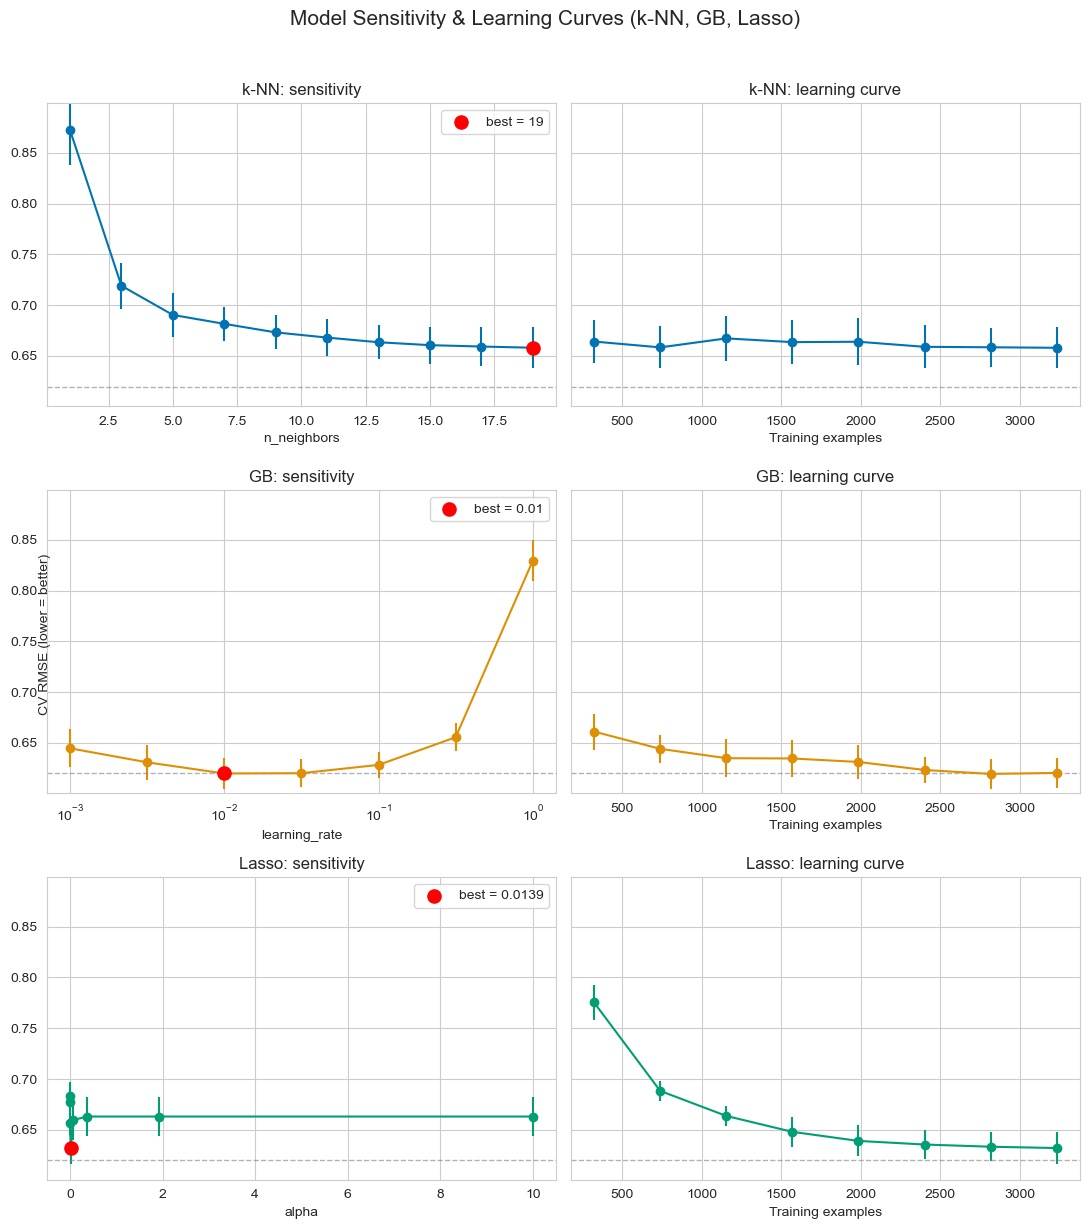

In [12]:
global_best = min(knn_rmse + gb_rmse + las_rmse)

sns.set_style("whitegrid")

palette = sns.color_palette("colorblind", 3)
fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharey=True)
models_info = [
    ('k-NN',  k_vals,     knn_rmse, knn_std, best_k,  palette[0],
     sizes_knn, lc_knn, std_knn),
    ('GB',    rates,      gb_rmse,  gb_std,  best_lr, palette[1],
     sizes_gb, lc_gb,  std_gb),
    ('Lasso', alphas,     las_rmse, las_std, best_a,  palette[2],
     sizes_las, lc_las, std_las)
]

for row, (name, x, rmse, err, best_x, color, s, lc_y, lc_std) in enumerate(models_info):
    # Sensitivity curve (left column)
    axes[row, 0].errorbar(x, rmse, yerr=err, marker='o', color=color)
    axes[row, 0].scatter(best_x, min(rmse), s=90, c='red', zorder=3,
                         label=f'best = {best_x:.3g}')
    if name == 'GB':
        axes[row, 0].set_xscale('log')
    axes[row, 0].set_xlabel({'k-NN':'n_neighbors', 'GB':'learning_rate', 'Lasso':'alpha'}[name])
    axes[row, 0].set_title(f'{name}: sensitivity'); axes[row, 0].legend()

    # Learning curve (right column)
    axes[row, 1].errorbar(s, lc_y, yerr=lc_std, marker='o', color=color)
    axes[row, 1].set_xlabel('Training examples')
    axes[row, 1].set_title(f'{name}: learning curve')

# consistent y-axis + baseline
all_vals = knn_rmse + gb_rmse + las_rmse + list(lc_knn) + list(lc_gb) + list(lc_las)
ymin, ymax = min(all_vals)*0.97, max(all_vals)*1.03
for ax in axes.ravel():
    ax.set_ylim(ymin, ymax)
    ax.axhline(global_best, ls='--', lw=1, color='grey', alpha=0.6)

fig.text(0.04, 0.5, 'CV RMSE (lower = better)', va='center', rotation='vertical')
fig.suptitle('Model Sensitivity & Learning Curves (k-NN, GB, Lasso)', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### Failure analysis  (worst three rows)

/var/folders/fy/v4z9p5hj31n955998nz_syv80000gn/T/ipykernel_29269/1818764126.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


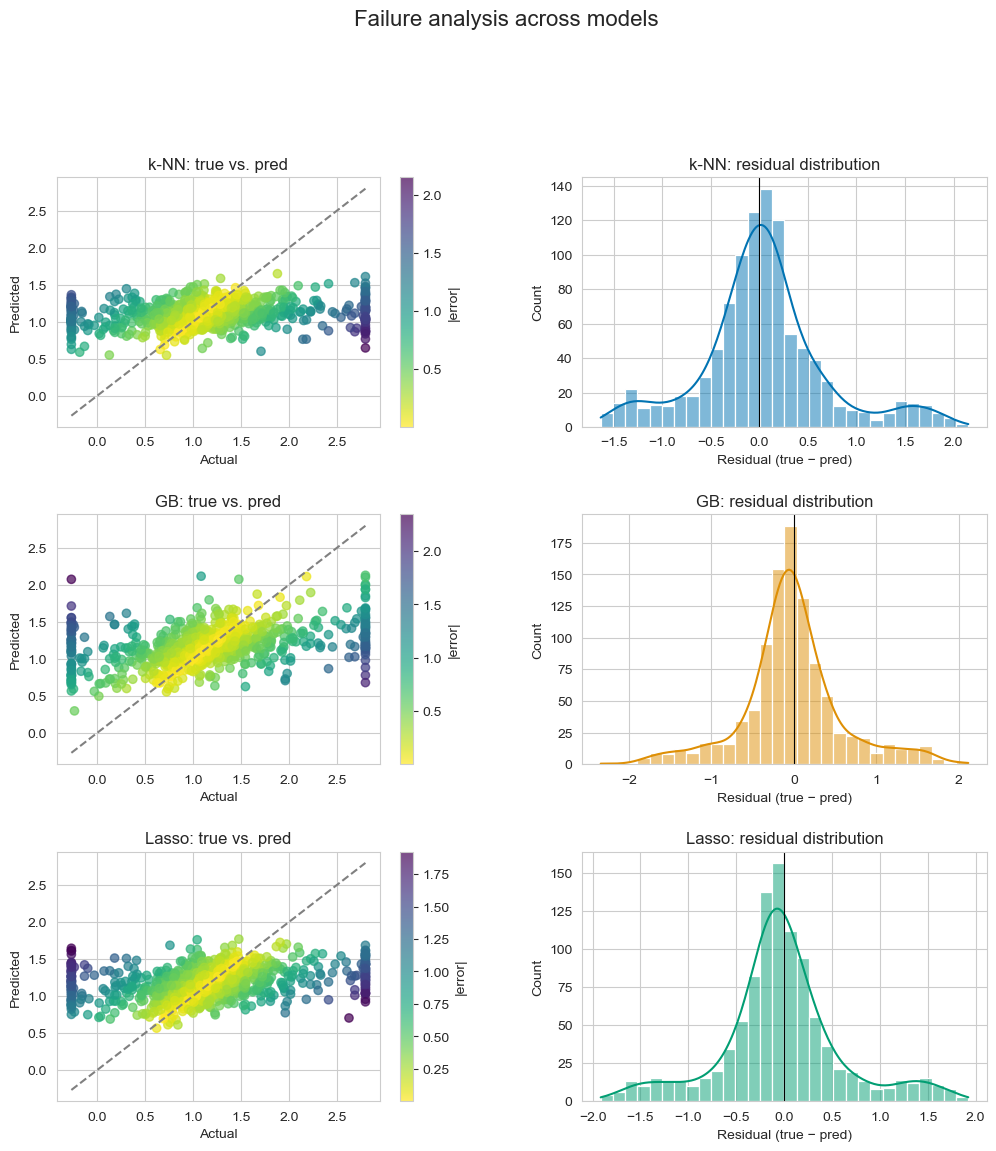

,k-NN
0,─


,true,pred,resid,abs_err
287,2.796562,0.644891,2.151670,2.151670
327,2.796562,0.765614,2.030948,2.030948
969,2.796562,0.834571,1.961991,1.961991
50,2.796562,0.860728,1.935834,1.935834
678,2.796562,0.868506,1.928055,1.928055
312,2.796562,0.869265,1.927297,1.927297
305,2.796562,0.874174,1.922388,1.922388
47,2.796562,0.900214,1.896347,1.896347
376,2.796562,0.919477,1.877085,1.877085
373,2.796562,0.954174,1.842387,1.842387


,GB
0,─


,true,pred,resid,abs_err
240,-0.270588,2.073696,-2.344284,2.344284
953,2.796562,0.677989,2.118572,2.118572
47,2.796562,0.778455,2.018106,2.018106
965,-0.270588,1.712859,-1.983447,1.983447
353,2.796562,0.883035,1.913526,1.913526
704,-0.270588,1.555702,-1.826291,1.826291
164,-0.270588,1.554125,-1.824714,1.824714
287,2.796562,0.980322,1.816240,1.816240
321,-0.270588,1.497323,-1.767911,1.767911
496,-0.270588,1.485523,-1.756111,1.756111


,Lasso
0,─


,true,pred,resid,abs_err
559,2.625000,0.701979,1.923021,1.923021
975,-0.270588,1.644288,-1.914876,1.914876
704,-0.270588,1.613661,-1.884249,1.884249
953,2.796562,0.919795,1.876767,1.876767
240,-0.270588,1.605744,-1.876333,1.876333
47,2.796562,0.955122,1.841439,1.841439
448,-0.270588,1.560038,-1.830627,1.830627
353,2.796562,1.026998,1.769564,1.769564
640,2.796562,1.036251,1.760310,1.760310
599,2.796562,1.037299,1.759263,1.759263


In [13]:
fitted = {
    name: clone(mdl).fit(X_train, y_train)
    for name, mdl in {
        'k-NN':  best_knn,
        'GB':    best_gb,
        'Lasso': best_las
    }.items()
}

errs = {}
for name, mdl in fitted.items():
    pred          = mdl.predict(X_test)
    df            = pd.DataFrame({'true': y_test, 'pred': pred})
    df['resid']   = df['true'] - df['pred']
    df['abs_err'] = df['resid'].abs()
    errs[name]    = df

sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(12, 12),
                         gridspec_kw={'wspace':0.3, 'hspace':0.35})

palette = sns.color_palette("colorblind", 3)

for i, (name, df) in enumerate(errs.items()):
    # (a) true vs pred scatter
    sc = axes[i,0].scatter(df['true'], df['pred'],
                           c=df['abs_err'], cmap='viridis_r', alpha=0.7)
    axes[i,0].plot([df['true'].min(), df['true'].max()],
                   [df['true'].min(), df['true'].max()],
                   ls='--', color='grey')
    axes[i,0].set_xlabel('Actual'); axes[i,0].set_ylabel('Predicted')
    axes[i,0].set_title(f'{name}: true vs. pred')
    fig.colorbar(sc, ax=axes[i,0], label='|error|')

    # (b) residual histogram
    sns.histplot(df['resid'], bins=30, kde=True,
                 ax=axes[i,1], color=palette[i])
    axes[i,1].axvline(0, color='k', lw=0.8)
    axes[i,1].set_xlabel('Residual (true − pred)')
    axes[i,1].set_title(f'{name}: residual distribution')

fig.suptitle('Failure analysis across models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


for name, df in errs.items():
    display(pd.DataFrame({name: '─'}, index=[0]))   # visual separator
    display(df.nlargest(10, 'abs_err').style.set_caption(f'Worst 10 – {name}'))

### Use the models to identify the most useful variable to predict the target

In [14]:
from sklearn.inspection import permutation_importance

# --- permutation importance for the tuned k-NN --------------------
TOP_N = 20

knn_best = best_models['k-NN']        # pipeline returned by tune_and_evaluate
perm = permutation_importance(
            knn_best, X_test, y_test,
            n_repeats=30,
            scoring='neg_root_mean_squared_error',
            random_state=42, n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X_test.columns)
top = imp.abs().nlargest(TOP_N)

print(f"Top {TOP_N} permutation importances (k-NN)")
for var, score in top.items():
    if var in new_categorical_variables:
        parts = var.split("_")
        cat_var, category = "_".join(parts[:-1]), parts[-1]
        category = int(category) if category.isdigit() else category
        label = categorical_variables_categories_dict[
                    variable_formats_dict[cat_var]][category]
        print(f"{var} | {variable_labels_dict[cat_var]} = {label} | ΔRMSE {score:.4f}")
    else:
        print(f"{var} | {variable_labels_dict[var]} | ΔRMSE {score:.4f}")

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Top 20 permutation importances (k-NN)
x08f_3 | How much did you use each of the following sources to get information about mortgages or mortgage lenders? |Newspaper/TV/Radio (Waves 4-34) = Not at all | ΔRMSE 0.0036
x08b_3 | How much did you use each of the following sources to get information about mortgages or mortgage lenders? |Other mortgage lenders/brokers = Not at all | ΔRMSE 0.0029
gse_1 | Government Sponsored Enterprise = Fannie Mae | ΔRMSE 0.0025
x23e_1 | During the application process were you told about mortgages with any of the following? | A lower interest rate in return for paying higher closing costs (discount points) = Yes | ΔRMSE 0.0025
x23e_2 | During the application process were you told about mortgages with any of the following? | A lower interest rate in return for paying higher closing costs (discount points) = No | ΔRMSE 0.0025
x37c_1_1 | How important, if at all, were the following reasons in your decision to refinance, modify, or obtain a new mortgage? | Get a l

In [15]:
# --- Lasso: top-N non-zero coefficients ---------------------------------
TOP_N = 20

lasso_coef = pd.Series(best_models['Lasso'].coef_, index=X_train.columns)
nz = (lasso_coef[lasso_coef != 0]
      .sort_values(key=np.abs, ascending=False)
      .head(TOP_N))

print(f"Top {len(nz)} non-zero Lasso coefficients")
for var, coef in nz.items():
    sign = "+" if coef > 0 else "-"
    if var in new_categorical_variables:
        parts = var.split("_")
        cat_var, category = "_".join(parts[:-1]), parts[-1]
        category = int(category) if category.isdigit() else category
        label = categorical_variables_categories_dict[
                    variable_formats_dict[cat_var]][category]
        print(f"{var} | {variable_labels_dict[cat_var]} = {label} | "
              f"coef {sign}{abs(coef):.4f}")
    else:
        print(f"{var} | {variable_labels_dict[var]} | coef {sign}{abs(coef):.4f}")


Top 20 non-zero Lasso coefficients
loan_type_1 | Mortgage Type = Conventional | coef +0.2491
x37e_1_3 | How important, if at all, were the following reasons in your decision to refinance, modify, or obtain a new mortgage? | Repay the loan more quickly (Waves 1-6) = Not at all | coef +0.1642
x66_5 | Which one of the following best describes how you use this property? = Rental or investment property | coef +0.1261
x17g_1_1 | How important were each of the following in determining the mortgage you took out? | A term of less than 30 years (Waves 1-6) = Very | coef -0.1116
loan_type_3 | Mortgage Type = VA guaranteed | coef -0.0916
x17g_2 | How important were each of the following in determining the mortgage you took out? | A term of 30 years (Waves 7-34) = Not important | coef +0.0911
x27b_1 | Overall, how satisfied are you that the mortgage you got was the one with the... | Lowest interest rate forwhich you could qualify = Very | coef -0.0787
x28a_2 | Overall, how satisfied are you with th

In [16]:
from sklearn.inspection import permutation_importance

# ---- permutation importance for HistGradientBoostingRegressor ---------
TOP_N = 20           # change if you want more/less
gb_best = best_models['GB']      # tuned model from tune_and_evaluate

perm = permutation_importance(
            gb_best, X_test, y_test,
            n_repeats=30,
            scoring='neg_root_mean_squared_error',
            random_state=42, n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X_test.columns)
top = imp.abs().nlargest(TOP_N)

print(f"Top {TOP_N} permutation importances (Gradient Boosting)")
for var, score in top.items():
    if var in new_categorical_variables:
        parts = var.split("_")
        cat_var, category = "_".join(parts[:-1]), parts[-1]
        category = int(category) if category.isdigit() else category
        label = categorical_variables_categories_dict[
                    variable_formats_dict[cat_var]][category]
        print(f"{var} | {variable_labels_dict[cat_var]} = {label} | "
              f"ΔRMSE {score:.4f}")
    else:
        print(f"{var} | {variable_labels_dict[var]} | ΔRMSE {score:.4f}")

Top 20 permutation importances (Gradient Boosting)
term | Mortgage Term (in Years) at Origination | ΔRMSE 0.0305
loan_type_1 | Mortgage Type = Conventional | ΔRMSE 0.0151
score_orig_r | VantageScore 3.0 at Origination | Respondent | ΔRMSE 0.0112
x08f_3 | How much did you use each of the following sources to get information about mortgages or mortgage lenders? |Newspaper/TV/Radio (Waves 4-34) = Not at all | ΔRMSE 0.0103
x17g_2 | How important were each of the following in determining the mortgage you took out? | A term of 30 years (Waves 7-34) = Not important | ΔRMSE 0.0096
loan_type_3 | Mortgage Type = VA guaranteed | ΔRMSE 0.0053
x44_1 | Does this mortgage have... | An adjustable rate (one that can change over the life of the loan)? = Yes | ΔRMSE 0.0044
loan_amount_cat_2 | Mortgage Loan Amount at Origination (Categorical) = $50,000 to  $99,999 | ΔRMSE 0.0034
gse_3 | Government Sponsored Enterprise = Federal Home Loan Bank | ΔRMSE 0.0023
x90b_2 | In the last couple of years, have any o

In [17]:
from sklearn.inspection import permutation_importance

# ---- permutation importance for HistGradientBoostingRegressor ---------
TOP_N = 20           # change if you want more/less
gb_best = best_models['GB']      # tuned model from tune_and_evaluate

perm = permutation_importance(
            gb_best, X_test, y_test,
            n_repeats=30,
            scoring='neg_root_mean_squared_error',
            random_state=42, n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X_test.columns)
top = imp.abs().nlargest(TOP_N)

print(f"Top {TOP_N} permutation importances (Gradient Boosting)")
for var, score in top.items():
    if var in new_categorical_variables:
        parts = var.split("_")
        cat_var, category = "_".join(parts[:-1]), parts[-1]
        category = int(category) if category.isdigit() else category
        label = categorical_variables_categories_dict[
                    variable_formats_dict[cat_var]][category]
        print(f"{var} | {variable_labels_dict[cat_var]} = {label} | "
              f"ΔRMSE {score:.4f}")
    else:
        print(f"{var} | {variable_labels_dict[var]} | ΔRMSE {score:.4f}")

Top 20 permutation importances (Gradient Boosting)
term | Mortgage Term (in Years) at Origination | ΔRMSE 0.0305
loan_type_1 | Mortgage Type = Conventional | ΔRMSE 0.0151
score_orig_r | VantageScore 3.0 at Origination | Respondent | ΔRMSE 0.0112
x08f_3 | How much did you use each of the following sources to get information about mortgages or mortgage lenders? |Newspaper/TV/Radio (Waves 4-34) = Not at all | ΔRMSE 0.0103
x17g_2 | How important were each of the following in determining the mortgage you took out? | A term of 30 years (Waves 7-34) = Not important | ΔRMSE 0.0096
loan_type_3 | Mortgage Type = VA guaranteed | ΔRMSE 0.0053
x44_1 | Does this mortgage have... | An adjustable rate (one that can change over the life of the loan)? = Yes | ΔRMSE 0.0044
loan_amount_cat_2 | Mortgage Loan Amount at Origination (Categorical) = $50,000 to  $99,999 | ΔRMSE 0.0034
gse_3 | Government Sponsored Enterprise = Federal Home Loan Bank | ΔRMSE 0.0023
x90b_2 | In the last couple of years, have any o

,MAE,RMSE,R2
model,,,
GB,0.4234,0.6112,0.1577
Lasso,0.4465,0.6352,0.0903
k-NN,0.4581,0.6520,0.0414
LinearRegression,0.4969,0.6806,-0.0445


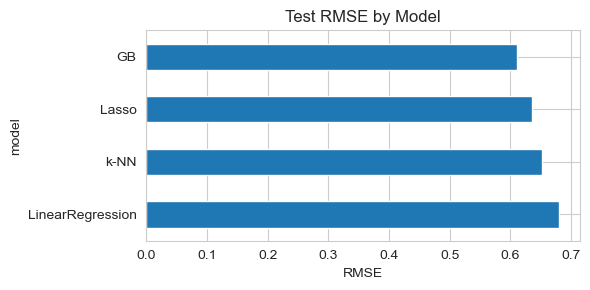

In [18]:
# ---------------------------------------------------------------------
# Compare all supervised models on the hold-out test set
# ---------------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def eval_model(name, est, X_test, y_test):
    """Return MAE, RMSE and R² for a fitted estimator."""
    y_pred = est.predict(X_test)
    return {
        'model': name,
        'MAE'  : mean_absolute_error(y_test, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2'   : r2_score(y_test, y_pred)
    }

# 1) collect metrics for every tuned model you kept in best_models
metrics = [eval_model(name, mdl, X_test, y_test)
           for name, mdl in best_models.items()]

# 2) (optional) simple OLS baseline for context
ols = LinearRegression().fit(X_train, y_train)
metrics.append(eval_model('LinearRegression', ols, X_test, y_test))

# 3) format & sort
results_df = (pd.DataFrame(metrics)
                .set_index('model')
                .sort_values('RMSE'))      # lower = better

display(results_df.style.format({'MAE':'{:.4f}',
                                 'RMSE':'{:.4f}',
                                 'R2':'{:.4f}'}))

# 4) quick visual
(results_df['RMSE']
   .plot(kind='barh', figsize=(6,3), title='Test RMSE by Model',
         legend=False)
   .invert_yaxis())
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()


## Business Question

**Can we predict the systematic risk (Beta) of mortgages in the FHFA NSMO portfolio using mortgage characteristics and macroeconomic factors?**


- **Which mortgage features (loan characteristics, borrower profiles, property details) are most predictive of mortgage Beta?**
- **How accurately can different ML models predict mortgage Beta?**
- **Which model family (probabilistic, tree-based, instance-based) performs best for this financial prediction task?**
